# Import

In [1]:
# Cài đặt thư viện chuyển đổi số thành chữ (dành cho đồ án)
!pip install num2words
import os
import csv
import re
import math
import numpy as np

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.util import ngrams
from collections import defaultdict, Counter
from nltk import pos_tag

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from num2words import num2words


In [2]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
folder_path = r"C:\uit_HK6\cs419\UIT_CacMonChuyenNganh\CS419_TruyXuatThongTin\project\Cranfield"
test_path = r"C:\uit_HK6\cs419\UIT_CacMonChuyenNganh\CS419_TruyXuatThongTin\project\TEST"
results_path = os.path.join(test_path, "RES")

# Đọc dữ liệu

In [4]:
'''
Đoạn code này dùng để load các tài liệu từ thư mục đã cho, docID là tên file , content là nội dung
Cấu trúc có dạng
{
    docID1: content1,
    docID2: content2,
    ...
}
'''
def loadDocuments(folder_path):
    documents = defaultdict(str)
    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            docID = int(filename.split('.')[0])
            with open(os.path.join(folder_path, filename), 'r', encoding='utf-8') as file:
                content = file.read()
                documents[docID] = content
    docIDs = list(documents.keys())
    return docIDs, documents

In [5]:
docID_list, documents = loadDocuments(folder_path)

In [6]:
if not documents:
    print("Không tìm thấy document nào trong thư mục.")
else:
    print(f"Số lượng document đã load: {len(documents)}")
    print(f"Nội dung document đầu tiên: {documents[1][:100]}...") if documents else print("Không có nội dung document nào để hiển thị.")

Số lượng document đã load: 1400
Nội dung document đầu tiên: experimental investigation of the aerodynamics of a wing in a slipstream . an experimental study of ...


# EDA

In [7]:
import re

def checkNumbersInDocuments(documents):
    docs_with_numbers = []
    total_numbers_found = 0
    
    for docID, text in documents.items():
        # Tìm tất cả các cụm chữ số (bao gồm số nguyên và số thập phân)
        numbers = re.findall(r'\b\d+(?:\.\d+)?\b', text)
        if numbers:
            docs_with_numbers.append(docID)
            total_numbers_found += len(numbers)
            
    print(f"--- THỐNG KÊ CHỮ SỐ TRONG DỮ LIỆU ---")
    print(f"- Có {len(docs_with_numbers)} / {len(documents)} tài liệu chứa chữ số.")
    print(f"- Tổng số lần xuất hiện của các con số: {total_numbers_found}")
    
    print("\n--- VÍ DỤ 5 TÀI LIỆU CÓ CHỨA SỐ ---")
    for docID in docs_with_numbers[:5]:
        nums = re.findall(r'\b\d+(?:\.\d+)?\b', documents[docID])
        # In tối đa 10 số đầu tiên để không bị trôi màn hình
        print(f"Tài liệu {docID}: {nums[:10]}") 

# Gọi hàm chạy thử
checkNumbersInDocuments(documents)


--- THỐNG KÊ CHỮ SỐ TRONG DỮ LIỆU ---
- Có 645 / 1400 tài liệu chứa chữ số.
- Tổng số lần xuất hiện của các con số: 3042

--- VÍ DỤ 5 TÀI LIỆU CÓ CHỨA SỐ ---
Tài liệu 100: ['1', '2']
Tài liệu 1000: ['10', '3', '5', '8', '5', '50', '3.5', '90', '000', '220']
Tài liệu 1001: ['0.65', '2.20']
Tài liệu 1002: ['14', '14']
Tài liệu 1003: ['0', '600', '6', '000', '80', '4', '000', '13']


# Xử lý dữ liệu

## Tạo danh sách Stopwords

In [8]:
# Load danh sách stopwords
stop_words = set(stopwords.words('english'))

# Bổ sung các số La Mã thường gặp trong đánh số mục không mang ý nghĩa
custom_stopwords = {'ii', 'iii', 'iv', 'vi', 'vii', 'viii', 'ix', 'xi', 'xii'}
stop_words.update(custom_stopwords)
print(f"Danh sách stopword có {len(stop_words)} từ.")

Danh sách stopword có 207 từ.


In [9]:
def computeTFIDFForStopwordsRemoval(documents):
    term_frequency = Counter()
    doc_frequency = defaultdict(set)
    
    def replace_num(match):
        try:
            return num2words(float(match.group())).replace('-', ' ').replace(',', '')
        except:
            return match.group()

    docID_list = list(documents.keys())
    for docID in docID_list:
        text_with_words = re.sub(r'\b\d+(?:\.\d+)?\b', replace_num, documents[docID])
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text_with_words).lower()
        tokens = word_tokenize(text)
        tokens = [word for word in tokens if not (len(word) == 1 and word.isalpha())]

        for token in tokens:
            term_frequency[token] += 1

        unique_tokens = set(tokens)
        for token in unique_tokens:
            doc_frequency[token].add(docID)

    N = len(documents)
    tfidf = {}
    for term, freq in term_frequency.items():
        df = len(doc_frequency[term])
        idf = math.log(N / df) if df > 0 else 0
        tfidf[term] = freq * idf

    sorted_tfidf = sorted(tfidf.items(), key=lambda x: x[1])

    with open("./tfidf_terms.csv", "w", newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(['Term', 'TF-IDF', 'Is Stopword'])
        for term, tfidf_score in sorted_tfidf:
            writer.writerow([
                term,
                round(tfidf_score, 6),
                "Yes" if term in stop_words else "No"
            ])
    print("Đã ghi kết quả TF-IDF vào file tfidf_terms.csv.")
    
computeTFIDFForStopwordsRemoval(documents)


Đã ghi kết quả TF-IDF vào file tfidf_terms.csv.


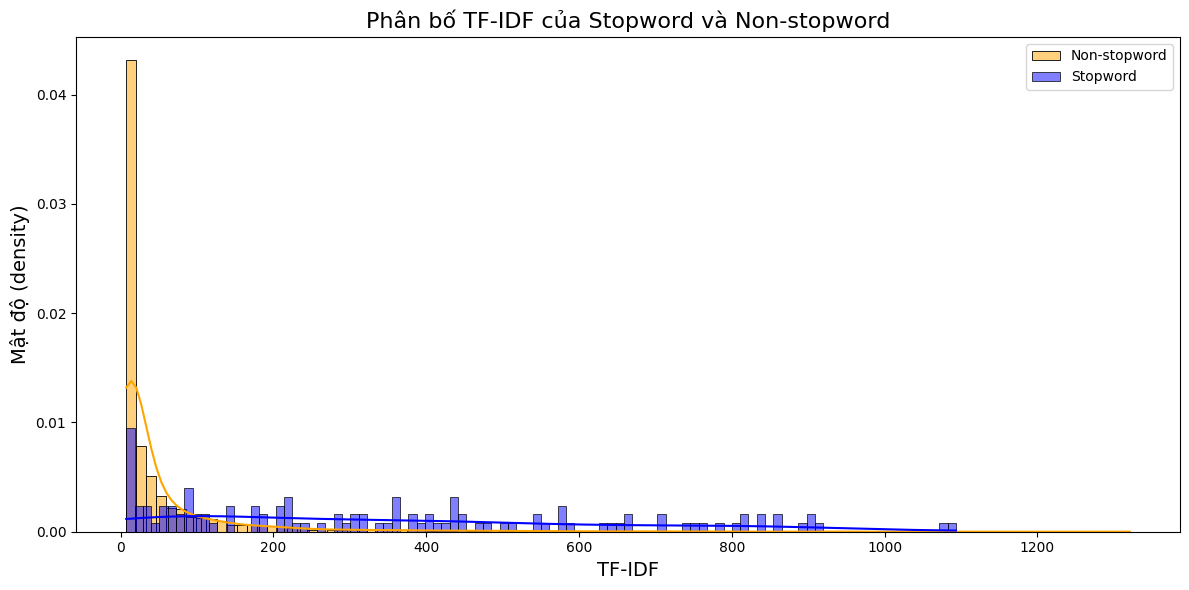

In [10]:
# Vẽ biểu đồ từ tfidf và stopword
df = pd.read_csv("./tfidf_terms.csv")

df['Is Stopword'] = df['Is Stopword'].map({'Yes': True, 'No': False})

# Tách 2 tập stopword và non-stopword
stopword_df = df[df['Is Stopword'] == True]
non_stopword_df = df[df['Is Stopword'] == False]

plt.figure(figsize=(12, 6))
sns.histplot(non_stopword_df["TF-IDF"], bins=100, color="orange", label="Non-stopword", stat="density", kde=True)
sns.histplot(stopword_df["TF-IDF"], bins=100, color="blue", label="Stopword", stat="density", kde=True)

plt.title("Phân bố TF-IDF của Stopword và Non-stopword", fontsize=16)
plt.xlabel("TF-IDF", fontsize=14)
plt.ylabel("Mật độ (density)", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## Lemmatize và Tokenize

In [11]:
# Chuyển đổi Penn Treebank POS tags sang WordNet POS tags
def getWordnetPos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Mặc định là danh từ nếu không khớp

In [12]:
lemmatizer = WordNetLemmatizer()

In [13]:
def processDocument(document):
    # Hàm phụ trợ: Chuyển đổi con số thành chữ (VD: 3.5 -> three point five)
    # Giúp bảo tồn ngữ nghĩa định lượng trong văn bản khoa học.
    def replace_num(match):
        try:
            return num2words(float(match.group())).replace('-', ' ').replace(',', '')
        except:
            return match.group()
           
    # 1. Khôi phục từ viết tắt học thuật (Abbreviation Expansion)
    abbr_dict = {
        r'\bfig\.?\b': 'figure',
        r'\bref\.?\b': 'reference',
        r'\bapprox\.?\b': 'approximately',
        r'\beq\.?\b': 'equation',
        r'\bsq\.?\b': 'square',
        r'\bno\.?\b': 'number',
        r'\be\.g\.?\b': 'for example',
        r'\bi\.e\.?\b': 'that is',
        r'\bsec\.?\b': 'section'
    }
    
    # Chuyển thành chữ thường để dễ replace
    expanded_text = document.lower()
    for pattern, replacement in abbr_dict.items():
        expanded_text = re.sub(pattern, replacement, expanded_text)

    # 2. Chuyển đổi toàn bộ số thành chữ
    text_with_words = re.sub(r'\b\d+(?:\.\d+)?\b', replace_num, expanded_text)
    
    # 3. Xóa sạch dấu câu, chỉ giữ lại chữ cái a-z và viết thường
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text_with_words)
    
    # 4. Tách văn bản thành từng từ (Tokenization)
    tokens = word_tokenize(text)
    
    # 5. Lọc bỏ các từ chỉ có 1 ký tự và các từ vô nghĩa (Stopwords)
    tokens = [word for word in tokens if not (len(word) == 1 and word.isalpha()) and word not in stop_words]

    # 6. Gắn nhãn từ loại (Danh từ, động từ...) để phục vụ Lemmatization
    tagged_tokens = pos_tag(tokens)

    # 7. Đưa từ về nguyên gốc dựa trên nhãn từ loại
    lemmatized_tokens = []
    for token, tag in tagged_tokens:
        wn_tag = getWordnetPos(tag)
        lemmatized_token = lemmatizer.lemmatize(token, pos=wn_tag)
        lemmatized_tokens.append(lemmatized_token)

    return lemmatized_tokens


In [14]:
# Duyệt qua các document và gôm các token đã xử lý vào một danh sách

all_tokens = []
process_documents = {}

for docID in docID_list:
    tokens = processDocument(documents[docID])
    process_documents[docID] = tokens
    all_tokens.extend(tokens)

print(f"Số lượng token sau khi xử lý: {len(all_tokens)}")

Số lượng token sau khi xử lý: 134069


## Tạo danh sách từ vựng (vocab) và chỉ mục từ vựng (vocab_idx)

In [15]:
all_terms = set()
for docID in docID_list:
    all_terms.update(process_documents[docID])

print(f"Tổng số term sau khi gộp bigram: {len(all_terms)}")

for docID in docID_list[:5]:
    print(f"Document {docID} có các term {process_documents[docID]}")

Tổng số term sau khi gộp bigram: 5947
Document 1 có các term ['experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'study', 'wing', 'propeller', 'slipstream', 'make', 'order', 'determine', 'spanwise', 'distribution', 'lift', 'increase', 'due', 'slipstream', 'different', 'angle', 'attack', 'wing', 'different', 'free', 'stream', 'slipstream', 'velocity', 'ratio', 'result', 'intend', 'part', 'evaluation', 'basis', 'different', 'theoretical', 'treatment', 'problem', 'comparative', 'span', 'load', 'curve', 'together', 'support', 'evidence', 'show', 'substantial', 'part', 'lift', 'increment', 'produce', 'slipstream', 'due', 'destalling', 'boundary', 'layer', 'control', 'effect', 'integrate', 'remain', 'lift', 'increment', 'subtract', 'destalling', 'lift', 'find', 'agree', 'well', 'potential', 'flow', 'theory', 'empirical', 'evaluation', 'destalling', 'effect', 'make', 'specific', 'configuration', 'experiment']
Document 10 có các term ['theory', 'impact', 'tu

In [16]:
vocab = sorted(all_terms)
vocab_index = {term: i for i, term in enumerate(vocab)}
print(f"Số lượng term trong vocab: {len(vocab)}")
print(f"Vocab index: {vocab_index}")

Số lượng term trong vocab: 5947
Vocab index: {'0degree': 0, '0degrees': 1, '100degrees': 2, '100x10': 3, '10degree': 4, '10degrees': 5, '10g': 6, '1103a': 7, '11in': 8, '12degree': 9, '1400degreek': 10, '14in': 11, '15degree': 12, '15x10': 13, '180degree': 14, '18degree': 15, '18in': 16, '1degree': 17, '1fa': 18, '1x10': 19, '200degree': 20, '20degree': 21, '20degreec': 22, '20degrees': 23, '24': 24, '25degree': 25, '25degrees': 26, '2n': 27, '2p': 28, '2x10': 29, '3000degreek': 30, '30degree': 31, '30th': 32, '3600degreek': 33, '3ft': 34, '40degree': 35, '45degree': 36, '45degrees': 37, '49degree': 38, '4degree': 39, '4degrees': 40, '4ft': 41, '4th': 42, '4x10': 43, '500degree': 44, '50degree': 45, '50degrees': 46, '55degrees': 47, '5d': 48, '5th': 49, '6000degreek': 50, '60degree': 51, '60degrees': 52, '63a2xx': 53, '63a4xx': 54, '64a010': 55, '65a004': 56, '65degree': 57, '6in': 58, '707a': 59, '75degree': 60, '75s': 61, '85degree': 62, '8n': 63, '8x10': 64, '90degree': 65, '99degre

# Mô hình

## Mô hình Vector

In [17]:
def computeQueryVector(query, vocab_index):
    query_tokens = processDocument(query)
    query_vector = np.zeros(len(vocab_index))

    query_bigrams = [' '.join(bigram) for bigram in ngrams(query_tokens, 2)]
    for bigram in query_bigrams:
        if bigram in vocab:
            query_tokens.append(bigram)

    for token in query_tokens:
        if token in vocab_index:
            query_vector[vocab_index[token]] += 1
    
    # Chuẩn hóa vector
    # norm = np.linalg.norm(query_vector)
    # if norm > 0:
    #     query_vector /= norm
    norm = len(query_tokens)
    if norm > 0:
        query_vector /= norm
        

    # print(f"Token sau khi xử lý: {query_tokens}")
    # print(f"Query vector: {query_vector}")
    return query_vector

In [18]:
def computeTF(tokens, vocab_index):
    tf_vector = np.zeros(len(vocab_index))
    for token in tokens:
        if token in vocab_index:
            tf_vector[vocab_index[token]] += 1
    n = len(tokens)
    if n > 0:
        tf_vector = tf_vector / n  # Chuẩn hóa TF
    return tf_vector

def computeGlobalDF(documents, vocab_index):
    df_vector = np.zeros(len(vocab_index))
    for tokens in documents.values():
        unique_tokens = set(tokens)
        for token in unique_tokens:
            if token in vocab_index:
                df_vector[vocab_index[token]] += 1
    return df_vector

def computeTFIDF(documents, vocab_index):
    N = len(documents)
    tfidf_matrix = np.zeros((N, len(vocab_index)))
    
    global_df = computeGlobalDF(documents, vocab_index)

    for docID, tokens in documents.items():
        tf_vector = computeTF(tokens, vocab_index)
        for i, term in enumerate(vocab):
            if tf_vector[i] > 0 and global_df[i] > 0:
                idf = math.log(N / global_df[i])
                tfidf_matrix[docID - 1][i] = round(tf_vector[i] * idf, 6)

    return tfidf_matrix


In [19]:
def getCandidateDocuments(query, inverted_index):
    query_tokens = processDocument(query)
    candidate_documents = set()

    for term in query_tokens:
        if term in inverted_index:
            candidate_documents.update([docID for docID,_ in inverted_index[term]['postings']])
            #print(f"Term '{term}' có trong inverted index, cập nhật candidate documents: {candidate_documents}")
    return candidate_documents

In [20]:
def cosineSimilarity(v1, v2):
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    return np.dot(v1, v2) / (norm1 * norm2) if norm1 and norm2 else 0.0

In [21]:
def createInvertedIndexForVS(tfidf_matrix, vocab_index):
    inverted_index = defaultdict(dict)
    df_dict = defaultdict(set) # Để lưu trữ DF cho từng term

    for docID, terms in process_documents.items():
        unique_terms = set(terms)
        for term in unique_terms:
            df_dict[term].add(docID)

    for term, docIDs in df_dict.items():
        term_index = vocab_index.get(term)
        if term_index is not None:
            posting_list = []
            for docID in docIDs:
                tfidf_value = tfidf_matrix[docID - 1][term_index]
                if tfidf_value > 0:
                    posting_list.append((docID, tfidf_value))

            if term in vocab_index:
                inverted_index[term]= {
                    'nDoc': len(docIDs),     # Số lượng tài liệu chứa term này
                    'postings': posting_list # Danh sách posting chứa (doc_id, tf-idf)
                }
    
    return inverted_index

In [22]:
# Tính toán TF-IDF cho các document đã gộp bigram
tfidf_matrix = computeTFIDF(process_documents, vocab_index)
print(f"Kích thước ma trận TF-IDF: {tfidf_matrix.shape}")

Kích thước ma trận TF-IDF: (1400, 5947)


In [23]:
# Tính toán inverted index từ ma trận TF-IDF
tfidf_inverted_index = createInvertedIndexForVS(tfidf_matrix, vocab_index)
print(f"Số lượng term trong inverted index: {len(tfidf_inverted_index)}")

Số lượng term trong inverted index: 5947


In [24]:
for term, data in list(tfidf_inverted_index.items())[:5]:
    print(f"Term: {term}, nDoc: {data['nDoc']}, Postings: {data['postings'][:5]}...")  # Hiển thị 3 posting đầu tiên

Term: wing, nDoc: 225, Postings: [(512, 0.045703), (1, 0.069423), (513, 0.080653), (520, 0.121875), (13, 0.100171)]...
Term: agree, nDoc: 55, Postings: [(1, 0.040973), (1027, 0.050576), (1157, 0.026974), (903, 0.026316), (648, 0.057802)]...
Term: flow, nDoc: 729, Postings: [(1, 0.00826), (2, 0.033753), (3, 0.072506), (4, 0.041652), (6, 0.011653)]...
Term: theory, nDoc: 456, Postings: [(1, 0.014199), (10, 0.037391), (13, 0.015366), (14, 0.040242), (15, 0.015159)]...
Term: study, nDoc: 237, Postings: [(1, 0.022483), (1025, 0.0166), (2, 0.030624), (514, 0.031161), (8, 0.020653)]...


In [25]:
# Tạo vector truy vấn
q = "what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft."
query_tokens = processDocument(q)
query_vector = computeQueryVector(q, vocab_index)

In [26]:
# Tìm kiếm các tài liệu ứng với truy vấn
candidate_documents = getCandidateDocuments(q, tfidf_inverted_index)
print(f"Số lượng tài liệu ứng với truy vấn: {len(candidate_documents)}")
for docID in sorted(candidate_documents)[:5]:
    print(f"Document ID: {docID}, Tokens: {process_documents[docID][:10]}...")  # Hiển thị 10 token đầu tiên

Số lượng tài liệu ứng với truy vấn: 820
Document ID: 2, Tokens: ['simple', 'shear', 'flow', 'past', 'flat', 'plate', 'incompressible', 'fluid', 'small', 'viscosity']...
Document ID: 5, Tokens: ['one', 'dimensional', 'transient', 'heat', 'conduction', 'double', 'layer', 'slab', 'subject', 'linear']...
Document ID: 6, Tokens: ['one', 'dimensional', 'transient', 'heat', 'flow', 'multilayer', 'slab', 'recent', 'contribution', 'reader']...
Document ID: 7, Tokens: ['effect', 'control', 'three', 'dimensional', 'roughness', 'boundary', 'layer', 'transition', 'supersonic', 'speed']...
Document ID: 8, Tokens: ['measurement', 'effect', 'two', 'dimensional', 'three', 'dimensional', 'roughness', 'element', 'boundary', 'layer']...


In [27]:
# Tính toán cosine similarity giữa truy vấn và các tài liệu ứng với truy vấn
similarities = []
for docID in candidate_documents:
    doc_vector = tfidf_matrix[docID - 1]
    similarity = cosineSimilarity(query_vector, doc_vector)
    similarities.append((docID, similarity))
# Sắp xếp các tài liệu theo độ tương đồng giảm dần
similarities.sort(key=lambda x: x[1], reverse=True)
# Hiển thị 10 tài liệu tương tự nhất
print("10 tài liệu tương tự nhất:")
for docID, similarity in similarities[:10]:
    print(f"Document ID: {docID}, Similarity: {similarity:.6f}, Tokens: {process_documents[docID][:10]}...")  # Hiển thị 10 token đầu tiên

10 tài liệu tương tự nhất:
Document ID: 51, Similarity: 0.259136, Tokens: ['theory', 'aircraft', 'structural', 'model', 'subject', 'aerodynamic', 'heating', 'external', 'load', 'problem']...
Document ID: 184, Similarity: 0.251059, Tokens: ['scale', 'model', 'thermo', 'aeroelastic', 'research', 'investigation', 'make', 'parameter', 'satisfy', 'thermo']...
Document ID: 359, Similarity: 0.239672, Tokens: ['note', 'hypersonic', 'similarity', 'law', 'unyawed', 'cone', 'know', 'hypersonic', 'similarity', 'law']...
Document ID: 12, Similarity: 0.239119, Tokens: ['structural', 'aerelastic', 'consideration', 'high', 'speed', 'flight', 'dominate', 'factor', 'structural', 'design']...
Document ID: 435, Similarity: 0.198434, Tokens: ['application', 'similar', 'solution', 'calculation', 'laminar', 'heat', 'transfer', 'body', 'yaw', 'large']...
Document ID: 56, Similarity: 0.192013, Tokens: ['analysis', 'applicability', 'hypersonic', 'similarity', 'law', 'study', 'flow', 'body', 'revolution', 'zero'

In [28]:
def searchVectorSpace(query, tfidf_matrix, inverted_index, vocab_index, k=20):
    query_vector = computeQueryVector(query, vocab_index)
    candidate_documents = getCandidateDocuments(query, inverted_index)

    similarities = []
    for docID in candidate_documents:
        doc_vector = tfidf_matrix[docID - 1]
        similarity = cosineSimilarity(query_vector, doc_vector)
        similarities.append((docID, similarity))

    # Sắp xếp các tài liệu theo độ tương đồng giảm dần
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    return similarities[:k]  # Trả về k tài liệu tương tự nhất

## Mô hình xác suất BIM

In [29]:
def createInvertedIndexForBIM(documents, vocab_index):
    df_dict = defaultdict(set)  # Để lưu trữ DF cho từng term

    # Tính DF cho từng term
    for docID, terms in documents.items():
        unique_terms = set(terms)
        for term in unique_terms:
            df_dict[term].add(docID)
    
    inverted_index = defaultdict(dict)
    for term, docIDs in df_dict.items():
        nDoc = len(docIDs)
        u = nDoc / len(documents) if len(documents) > 0 else 0
        p = 0.5
        posting_list = []

        if u in [0, 1]:
            continue

        w = math.log(p/(1-p)) - math.log(u/(1-u)) # Tính trọng số w với log-odds

        posting_list = [(docID, w) for docID in docIDs if term in vocab_index]

        inverted_index[term] = {
            'nDoc': nDoc,  # Số lượng tài liệu chứa term này
            'postings': posting_list  # Danh sách posting chứa (doc_id, w)
        }
        
    return inverted_index

In [30]:
def computeBIM(query, inverted_index, k=20):
    query_tokens = processDocument(query)
    score = defaultdict(float)

    for term in set(query_tokens):
        if term in inverted_index:
            postings = inverted_index[term]['postings']
            for docID, w in postings:
                score[docID] += w
    # Sắp xếp các tài liệu theo điểm số giảm dần
    sorted_scores = sorted(score.items(), key=lambda x: x[1], reverse=True)
    return sorted_scores[:k]


In [31]:
inverted_index_bim = createInvertedIndexForBIM(process_documents, vocab_index)
print(f"Đã tạo inverted index cho BIM với {len(inverted_index_bim)} term.")
print("Ví dụ về inverted index cho một số term:")
for term in list(inverted_index_bim.keys())[:5]:
    print(f"{term}: {inverted_index_bim[term]}")

Đã tạo inverted index cho BIM với 5947 term.
Ví dụ về inverted index cho một số term:
wing: {'nDoc': 225, 'postings': [(512, 1.6529230243738393), (1, 1.6529230243738393), (513, 1.6529230243738393), (520, 1.6529230243738393), (13, 1.6529230243738393), (14, 1.6529230243738393), (30, 1.6529230243738393), (31, 1.6529230243738393), (545, 1.6529230243738393), (547, 1.6529230243738393), (1062, 1.6529230243738393), (1064, 1.6529230243738393), (42, 1.6529230243738393), (561, 1.6529230243738393), (1074, 1.6529230243738393), (1075, 1.6529230243738393), (52, 1.6529230243738393), (60, 1.6529230243738393), (1089, 1.6529230243738393), (1090, 1.6529230243738393), (1091, 1.6529230243738393), (1092, 1.6529230243738393), (69, 1.6529230243738393), (1094, 1.6529230243738393), (1095, 1.6529230243738393), (76, 1.6529230243738393), (78, 1.6529230243738393), (1108, 1.6529230243738393), (1111, 1.6529230243738393), (599, 1.6529230243738393), (600, 1.6529230243738393), (601, 1.6529230243738393), (1115, 1.65292302

In [32]:
df_dict = dict(zip(vocab, df))  # Chuyển đổi df sang dict để truy cập nhanh
results = computeBIM(q, inverted_index_bim, k=20)
print(f"Số lượng tài liệu phù hợp với truy vấn BIM: {len(results)}")
# In top 10 tài liệu
print("Top tài liệu phù hợp với truy vấn BIM:")
print("results", results)

for doc_id, score in results:
    print(f"Doc {doc_id} - Score: {score:.4f}")

Số lượng tài liệu phù hợp với truy vấn BIM: 20
Top tài liệu phù hợp với truy vấn BIM:
results [(486, 16.798939410324323), (329, 14.918573695105485), (184, 12.597852222206537), (14, 11.89287969091098), (51, 11.613066347367324), (12, 11.284892702541237), (573, 11.064179153340172), (78, 10.656117063762053), (944, 10.415340599804267), (576, 9.144938549894388), (1268, 9.144938549894388), (1003, 9.11381134460034), (1361, 9.101849868531005), (663, 9.080957178529546), (141, 8.96337750923905), (685, 8.96337750923905), (172, 8.816602913709376), (665, 8.564274172806675), (25, 7.92563132837195), (1335, 7.877048717451413)]
Doc 486 - Score: 16.7989
Doc 329 - Score: 14.9186
Doc 184 - Score: 12.5979
Doc 14 - Score: 11.8929
Doc 51 - Score: 11.6131
Doc 12 - Score: 11.2849
Doc 573 - Score: 11.0642
Doc 78 - Score: 10.6561
Doc 944 - Score: 10.4153
Doc 576 - Score: 9.1449
Doc 1268 - Score: 9.1449
Doc 1003 - Score: 9.1138
Doc 1361 - Score: 9.1018
Doc 663 - Score: 9.0810
Doc 141 - Score: 8.9634
Doc 685 - Scor

In [33]:
def searchBIM(query, inverted_index_bim, k=20):
    results = computeBIM(query, inverted_index_bim, k)
    return results

# Đánh giá mô hình

## Các độ đo

### Precision at k
- Đánh giá chất lượng top k kết quả - tỷ lệ tài liệu liên quan trong top-k tài liệu đầu tiên được truy xuất.

$$
\begin{align}
Precision@k= \frac{Số-tài-liệu-liên-quan-trong-top-k}{k}
\end{align}
$$

In [34]:
def precisionAtK(retrieved, relevant, k=10): 
    if k == 0:
        return 0.0
    retrieved_at_k = retrieved[:k]
    relevant_set = set(relevant)
    relevant_count = sum(1 for doc in retrieved_at_k if doc in relevant_set)
    return relevant_count / k

### Average Precision
- Cân nhất cả thức tự và độ chính xác của các truy vấn - trung bình độ chính xác tại mỗi vị trí mà tài liệu liên quan xuất hiện.

$$
\begin{align}
AP = \frac{1}{Số-tài-liệu-liên-quan} \sum P@i (i = 1...n)
\end{align}
$$

In [35]:
def avaragePrecision(retrieved, relevant):
    if not relevant:
        return 0.0
    precision_sum = 0.0
    for rank, docID in enumerate(retrieved, start=1):
        if docID in relevant:
            precision_sum += precisionAtK(retrieved, relevant, rank)
    return precision_sum / len(relevant)


### Mean Average Precision
- Đánh giá tổng thế tất cả truy vấn - trung bình Average Precision của tất cả các truy vấn.

$$
\begin{align}
MAP = \frac{1}{Số-lượng-truy-vấn} \sum AP(q) (q thuộc Q)
\end{align}
$$

In [36]:
def meanAveragePrecision(retrieved, relevant):
    total_ap = 0.0
    for query_id in retrieved:
        total_ap += avaragePrecision(retrieved[query_id], relevant[query_id])
    return total_ap / len(retrieved)

### Mean Reciprocal Rank
- Quan tâm đến tài liệu liên quan đầu tiên - trung bình nghịch đảo của vị trí đầu tiên mà một tài liệu liên quan xuất hiện.

$$
\begin{align}
MRR = \frac{1}{Số-lượng-truy-vấn} \sum \frac{1}{rank_i} (i = 1...|Q|)
\end{align}
$$

In [37]:
def meanReciprocalRank(retrieved, relevant):
    total_mrr = 0.0
    for query_id in retrieved:
        for rank, doc in enumerate(retrieved[query_id], start=1):
            if doc in relevant[query_id]:
                total_mrr += 1 / rank
                break
    return total_mrr / len(retrieved)

### MAP 11 điểm nội suy
- Vẽ đường cong precision-recall tại 11 mốc recall tiêu chuẩn từ 0.0 → 1.0 (gồm: 0.0, 0.1, ..., 1.0).

$$
\begin{align}
Recall@k = \frac{Số-tài-liệu-liên-quan-từ-đầu-đến-vị-trí-k}{Tổng-số-tài-liệu-liên-quan}
\end{align}
$$

In [38]:
def recallAtK(retrieved, relevant, k=10):
    if k == 0:
        return 0.0
    retrieved_at_k = retrieved[:k]
    relevant_set = set(relevant)
    relevant_count = sum(1 for doc in retrieved_at_k if doc in relevant_set)
    return relevant_count / len(relevant)

$$
\begin{align}
Precision@k = \frac{Số-tài-liệu-liên-quan-từ-đầu-đến-vị-trí-k}{k}
\end{align}
$$

In [39]:
def precisionAtK(retrieved, relevant, k=10):
    if k == 0:
        return 0.0
    retrieved_at_k = retrieved[:k]
    relevant_set = set(relevant)
    relevant_count = sum(1 for doc in retrieved_at_k if doc in relevant_set)
    return relevant_count / k

$$
\begin{align}
P_{interp}(r) = max P(r') (r'>=r)
\end{align}
$$

→ Với mỗi mức recall r, lấy precision cao nhất đạt được ở mức recall ≥ r.

In [40]:
RECALL_POINTS = np.linspace(0.0, 1.0, 11)
def interpolatedRecallPrecision(retrieved, relevant):
    precision = []
    recall = []

    # Duyệt qua từng tài liệu trong retrieved, tính toán precision và recall tại mỗi vị trí k
    for i, docID in enumerate(retrieved, start=1):
        if docID in relevant:
            precision.append(precisionAtK(retrieved, relevant, i))
            recall.append(recallAtK(retrieved, relevant, i))
    
    # Tìm precision tại các điểm recall từ 0 đến 1
    interpolated = []
    for rp in RECALL_POINTS:
        p_at_r = [p for p, r in zip(precision, recall) if r >= rp]
        if p_at_r:
            interpolated.append(max(p_at_r))
        else:
            interpolated.append(0.0)

    return interpolated


In [41]:
def meanInterpolatedRecallPrecision(all_retrieved, all_relevant):
    interpolated_all = []

    for qid in all_retrieved:
        retrieved = all_retrieved[qid]
        relevant = all_relevant.get(qid, set())
        if relevant:
            interpolated = interpolatedRecallPrecision(retrieved, relevant)
            interpolated_all.append(interpolated)

    if not interpolated_all:
        return [0.0] * 11  # không có truy vấn nào hợp lệ

    return np.mean(interpolated_all, axis=0)

In [42]:
def evaluateModel(retrieved, relevant):
    map_score = meanAveragePrecision(retrieved, relevant)
    mrr_score = meanReciprocalRank(retrieved, relevant)

    print(f"Mean Average Precision (MAP): {map_score:.4f}")
    print(f"Mean Reciprocal Rank (MRR): {mrr_score:.4f}")
    print("Mean Interpolated Precision at 11 recall points:")
    mean_map11 = meanInterpolatedRecallPrecision(retrieved, relevant)
    for r, p in zip(np.linspace(0, 1, 11), mean_map11):
        print(f"Recall {r:.1f}: Avg Precision {p:.4f}")
    
    print(f"\nMean Interpolated Precision at 11 recall points (tất cả truy vấn): {np.mean(mean_map11):.4f}")



## Xử lý truy vấn

In [43]:
def processTest(result_path):
    test_files = os.listdir(result_path)
    results = defaultdict(dict)

    for file in test_files:
        query_id = int(file.split('.')[0])
        results[query_id] = []

        # Đọc file kết quả
        result_df = pd.read_csv(os.path.join(result_path, file), sep="\s+", header=None)
        result_df.columns = ["QueryID", "DocID", "Rating"]

        # Chuyển đổi sang định dạng dict để truy cập nhanh
        for _, row in result_df.iterrows():
            results[query_id].append(int(row["DocID"]))
    return results


In [44]:
def loadQueries(query_file):
    queries = defaultdict(dict)
    with open(query_file, 'r', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter='\t')
        for row in reader:
            if len(row) < 2:
                continue
            query_id = int(row[0])
            query_text = row[1]
            queries[query_id] = query_text
    return queries

In [45]:
query_rels = processTest(results_path)
print(f"Đã xử lý {len(query_rels)} truy vấn từ kết quả.")
print("Tài liệu liên quan của truy vấn 1:", query_rels[1])
print("Tài liệu liên quan của truy vấn 2:", query_rels[2])

Đã xử lý 225 truy vấn từ kết quả.
Tài liệu liên quan của truy vấn 1: [184, 29, 31, 12, 51, 102, 13, 14, 15, 57, 378, 859, 185, 30, 37, 52, 142, 195, 875, 56, 66, 95, 462, 497, 858, 876, 879, 880, 486]
Tài liệu liên quan của truy vấn 2: [12, 15, 184, 858, 51, 102, 202, 14, 52, 380, 746, 859, 948, 285, 390, 391, 442, 497, 643, 856, 857, 877, 864, 658, 486]


In [46]:
query_file = test_path + "/query.txt"
all_query = loadQueries(query_file)
if not all_query:
    print("Không tìm thấy truy vấn nào trong file query.txt.")

print(f"Đã tải {len(all_query)} truy vấn từ file query.txt.")
print("Ví dụ truy vấn 1:", all_query[1])
print("Ví dụ truy vấn 2:", all_query[2])

Đã tải 225 truy vấn từ file query.txt.
Ví dụ truy vấn 1: what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft .
Ví dụ truy vấn 2: what are the structural and aeroelastic problems associated with flight of high speed aircraft .


## Đánh giá trên mô hình Vector

In [47]:
tfdif_results = {}
for query_id, query_text in all_query.items():
    results = searchVectorSpace(query_text, tfidf_matrix, tfidf_inverted_index, vocab_index, k=20)
    tfdif_results[query_id] = [docID for docID, _ in results]
print(f"Đã tìm kiếm {len(tfdif_results)} truy vấn với mô hình Vector Space.")
evaluateModel(tfdif_results, query_rels)

Đã tìm kiếm 225 truy vấn với mô hình Vector Space.
Mean Average Precision (MAP): 0.3105
Mean Reciprocal Rank (MRR): 0.7382
Mean Interpolated Precision at 11 recall points:
Recall 0.0: Avg Precision 0.7581
Recall 0.1: Avg Precision 0.7325
Recall 0.2: Avg Precision 0.5854
Recall 0.3: Avg Precision 0.4342
Recall 0.4: Avg Precision 0.3406
Recall 0.5: Avg Precision 0.2839
Recall 0.6: Avg Precision 0.1906
Recall 0.7: Avg Precision 0.1246
Recall 0.8: Avg Precision 0.0889
Recall 0.9: Avg Precision 0.0525
Recall 1.0: Avg Precision 0.0525

Mean Interpolated Precision at 11 recall points (tất cả truy vấn): 0.3313


## Đánh giá trên mô hình xác suất BIM

In [48]:
bim_results = {}
for query_id, query_text in all_query.items():
    results = searchBIM(query_text, inverted_index_bim, k=20)
    bim_results[query_id] = [docID for docID, _ in results]
print(f"Đã tìm kiếm {len(bim_results)} truy vấn với mô hình BIM.")
evaluateModel(bim_results, query_rels)

Đã tìm kiếm 225 truy vấn với mô hình BIM.
Mean Average Precision (MAP): 0.2610
Mean Reciprocal Rank (MRR): 0.6436
Mean Interpolated Precision at 11 recall points:
Recall 0.0: Avg Precision 0.6729
Recall 0.1: Avg Precision 0.6353
Recall 0.2: Avg Precision 0.5142
Recall 0.3: Avg Precision 0.3858
Recall 0.4: Avg Precision 0.2893
Recall 0.5: Avg Precision 0.2360
Recall 0.6: Avg Precision 0.1448
Recall 0.7: Avg Precision 0.0925
Recall 0.8: Avg Precision 0.0580
Recall 0.9: Avg Precision 0.0433
Recall 1.0: Avg Precision 0.0433

Mean Interpolated Precision at 11 recall points (tất cả truy vấn): 0.2832


## Đánh giá trên mô hình BM25

In [49]:
import math
from collections import Counter

class BM25:
    def __init__(self, processed_docs, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.doc_len = {}
        self.doc_freqs = {}
        self.idf = {}
        self.nd = {}
        self.N = len(processed_docs)
        self.avgdl = 0
        
        self._initialize(processed_docs)
        
    def _initialize(self, processed_docs):
        total_len = 0
        for docID, tokens in processed_docs.items():
            self.doc_len[docID] = len(tokens)
            total_len += len(tokens)
            
            frequencies = Counter(tokens)
            self.doc_freqs[docID] = frequencies
            
            for word in frequencies.keys():
                self.nd[word] = self.nd.get(word, 0) + 1
                
        self.avgdl = total_len / self.N if self.N > 0 else 0
        
        for word, freq in self.nd.items():
            # Công thức IDF chuẩn của BM25
            idf = math.log(((self.N - freq + 0.5) / (freq + 0.5)) + 1.0)
            self.idf[word] = idf
            
    def get_scores(self, query_tokens, k=20):
        scores = {}
        for docID, freq_dict in self.doc_freqs.items():
            score = 0.0
            doc_len = self.doc_len[docID]
            for q in query_tokens:
                if q not in freq_dict:
                    continue
                f = freq_dict[q]
                numerator = self.idf.get(q, 0) * f * (self.k1 + 1)
                denominator = f + self.k1 * (1 - self.b + self.b * doc_len / self.avgdl)
                score += numerator / denominator
            if score > 0:
                scores[docID] = score
                
        sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return sorted_scores[:k]

# Khởi tạo mô hình BM25 với tập process_documents đã có
bm25_model = BM25(process_documents)

def searchBM25(query_text, bm25_model, k=20):
    query_tokens = processDocument(query_text)
    results = bm25_model.get_scores(query_tokens, k=k)
    return results

bm25_results = {}
for query_id, query_text in all_query.items():
    results = searchBM25(query_text, bm25_model, k=20)
    bm25_results[query_id] = [docID for docID, _ in results]

print(f"Đã tìm kiếm {len(bm25_results)} truy vấn với mô hình BM25.")
evaluateModel(bm25_results, query_rels)


Đã tìm kiếm 225 truy vấn với mô hình BM25.
Mean Average Precision (MAP): 0.3576
Mean Reciprocal Rank (MRR): 0.7834
Mean Interpolated Precision at 11 recall points:
Recall 0.0: Avg Precision 0.7975
Recall 0.1: Avg Precision 0.7654
Recall 0.2: Avg Precision 0.6348
Recall 0.3: Avg Precision 0.5001
Recall 0.4: Avg Precision 0.4153
Recall 0.5: Avg Precision 0.3526
Recall 0.6: Avg Precision 0.2294
Recall 0.7: Avg Precision 0.1663
Recall 0.8: Avg Precision 0.1294
Recall 0.9: Avg Precision 0.0815
Recall 1.0: Avg Precision 0.0815

Mean Interpolated Precision at 11 recall points (tất cả truy vấn): 0.3776
